In [1]:
%pip install pandas numpy matplotlib statsmodels scikit-learn xgboost-cpu


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

def metricas_regr(y_true, y_pred) -> dict:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    bias = float(np.mean(y_true - y_pred))
    # regressão pred ~ obs (para Slope/Intercept no seu padrão)
    lr = LinearRegression().fit(np.array(y_true).reshape(-1,1), np.array(y_pred))
    slope = float(lr.coef_[0]); intercept = float(lr.intercept_)
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Bias (obs - prev)": bias,
            "Slope pred~obs": slope, "Intercept": intercept}

def walk_forward_tabular(X: pd.DataFrame, y: pd.Series, model_factory, train_size: int):
    preds, idxs = [], []
    for i in range(train_size, len(X)):
        X_tr, y_tr = X.iloc[:i, :], y.iloc[:i]
        X_te = X.iloc[[i], :]
        m = model_factory()
        m.fit(X_tr, y_tr)
        preds.append(float(m.predict(X_te)[0]))
        idxs.append(X.index[i])
    return pd.Series(preds, index=idxs)

def walk_forward_arimax(endog: pd.Series, exog: pd.DataFrame,
                          train_size: int, order=(1,0,0), h: int = 3):
    """Prevê h-passos à frente com reestimação a cada ponto."""
    preds, idxs = [], []
    # precisamos ter exógenas futuras conhecidas até i+h
    for i in range(train_size, len(endog) - h + 1):
        y_tr  = endog.iloc[:i]
        X_tr  = exog.iloc[:i, :]
        X_fut = exog.iloc[i:i+h, :]     # exógenas conhecidas para os próximos h meses

        model = SARIMAX(y_tr, exog=X_tr, order=order,
                        enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)

        fc_h = res.get_forecast(steps=h, exog=X_fut).predicted_mean.iloc[-1]  # passo h
        preds.append(float(fc_h))
        idxs.append(endog.index[i + h - 1])  # alinhar na data t+h
    return pd.Series(preds, index=idxs)

In [3]:
CAMINHO_BASE = "base_series.csv"  # ajuste se necessário

dados_analise = pd.read_csv(CAMINHO_BASE, index_col=0)
dados_analise["data"] = pd.to_datetime(dados_analise["data"])

dados_analise = dados_analise[dados_analise["data"] <= "2025-12-31"].copy()
dados_analise = dados_analise.sort_values("data").reset_index(drop=True)

print(f"Período da base: {dados_analise['data'].min().date()} até {dados_analise['data'].max().date()}")
print(f"Número de observações: {len(dados_analise)}")
display(dados_analise.head())

SPLIT_DATE  = "01/01/2023"

Período da base: 2019-01-01 até 2025-12-01
Número de observações: 84


,data,inad_total,saldo_total,concessao_total,juros_total,ipca,selic
0,2019-01-01,2.95,3237076.0,284019.0,24.46,0.32,6.5
1,2019-02-01,2.91,3247396.0,284219.0,24.79,0.43,6.5
2,2019-03-01,2.99,3273000.0,297678.0,25.07,0.75,6.5
3,2019-04-01,3.02,3272570.0,304796.0,25.13,0.57,6.5
4,2019-05-01,3.05,3291212.0,329959.0,24.96,0.13,6.5


In [4]:
# === Seleção de ordem por AIC no conjunto de treino ===
def escolher_ordem_arimax(y, X, train_size, candidatos=((1,0,0),(1,0,1),(2,0,0),(2,0,1),(1,1,0),(1,1,1))):
    y_tr = y.iloc[:train_size]
    X_tr = X.iloc[:train_size, :]
    melhor = None
    for order in candidatos:
        try:
            res = SARIMAX(y_tr, exog=X_tr, order=order,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            aic = res.aic
            if (melhor is None) or (aic < melhor[0]):
                melhor = (aic, order)
        except Exception:
            pass
    return melhor[1] if melhor else (1,0,0)

In [ ]:
# =========================
# ARIMAX — horizonte H=3 (fixando L6 para saldo/concessão e L3 para juros)
# =========================
if "dados_analise" not in globals():
    raise NameError("Defina 'dados_analise' antes de rodar este bloco.")

base = dados_analise.copy()

# 1) Criar defasagens necessárias (só se faltarem)
if "saldo_total_L6" not in base.columns:      base["saldo_total_L6"]      = base["saldo_total"].shift(6)
if "concessao_total_L6" not in base.columns:  base["concessao_total_L6"]  = base["concessao_total"].shift(6)
if "juros_total_L6" not in base.columns:      base["juros_total_L6"]      = base["juros_total"].shift(6)


# 2) Exógenas escolhidas (sem Selic p/ reduzir colinearidade)
exog_cols_h3 = ["saldo_total_L6","concessao_total_L6","juros_total_L6"]


dfm_h3 = base[["inad_total"] + exog_cols_h3].dropna()
y_h3    = dfm_h3["inad_total"]
exog_h3 = dfm_h3[exog_cols_h3]

# 3) Split temporal

datas_h3 = base.loc[dfm_h3.index, "data"]
train_size_h3 = (datas_h3 < pd.to_datetime(SPLIT_DATE)).sum()
if train_size_h3 <= 0:
    raise ValueError("SPLIT_DATE produziu treino vazio em H=3.")

# 4) Seleção de ordem por AIC (apenas d=0 para evitar 'shrink' multi-step)
if "escolher_ordem_arimax_d0" not in globals():
    def escolher_ordem_arimax_d0(y, X, train_size, candidatos=((1,0,0),(1,0,1),(2,0,0),(2,0,1))):
        y_tr, X_tr = y.iloc[:train_size], X.iloc[:train_size, :]
        melhor = None
        for order in candidatos:
            try:
                res = SARIMAX(y_tr, exog=X_tr, order=order,
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                aic = res.aic
                if (melhor is None) or (aic < melhor[0]): melhor = (aic, order)
            except Exception:
                pass
        return melhor[1] if melhor else (1,0,0)

ordem_h3 = escolher_ordem_arimax_d0(y_h3, exog_h3, train_size_h3)

# 5) Walk-forward (h=3) e métricas
yhat_h3   = walk_forward_arimax(endog=y_h3, exog=exog_h3, train_size=train_size_h3, order=ordem_h3, h=3)
y_true_h3 = y_h3.loc[yhat_h3.index]
res_h3    = metricas_regr(y_true_h3, yhat_h3)

# 6) Bias correction (remove o erro sistemático)
bias_h3     = (y_true_h3 - yhat_h3).mean()
yhat_h3_bc  = yhat_h3 + bias_h3
res_h3_bc   = metricas_regr(y_true_h3, yhat_h3_bc)

# 7) Tabela final
tabela_h3 = pd.DataFrame([
    {"Modelo": f"ARIMAX (h=3, ordem={ordem_h3}, L6 saldo/concessão, L6 juros)", **res_h3},
    {"Modelo": f"ARIMAX (h=3, ordem={ordem_h3}, L6 saldo/concessão, L6 juros) + bias", **res_h3_bc},
]).set_index("Modelo").round(6)
display(tabela_h3)

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/st

,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"ARIMAX (h=3, ordem=(2, 0, 0), L6 saldo/concessão, L3 juros)",0.150503,0.187429,0.557769,0.058391,0.710883,0.933024
"ARIMAX (h=3, ordem=(2, 0, 0), L6 saldo/concessão, L3 juros) + bias",0.140495,0.178102,0.600690,0.000000,0.710883,0.991415


In [6]:

%pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
# =========================
# XGBoost — horizonte H=3 (direto), base: dados_analise
# =========================
if "dados_analise" not in globals():
    raise NameError("Defina 'dados_analise' antes de rodar este bloco.")

base = dados_analise.copy()

# 1) Criar as defasagens necessárias (mesmas do ARIMAX h=3)
if "saldo_total_L6" not in base.columns:      base["saldo_total_L6"]      = base["saldo_total"].shift(6)
if "concessao_total_L6" not in base.columns:  base["concessao_total_L6"]  = base["concessao_total"].shift(6)
if "juros_total_L6" not in base.columns:      base["juros_total_L6"]      = base["juros_total"].shift(6)


# 2) Features e target direto (y_{t+3})
exog_cols_h3 = ["saldo_total_L6","concessao_total_L6","juros_total_L6"]

H = 3
base["target_h3"] = base["inad_total"].shift(-H)

df_dir = base[["data"] + exog_cols_h3 + ["target_h3"]].dropna().copy()
X_dir  = df_dir[exog_cols_h3]
y_dir  = df_dir["target_h3"]

# Split temporal (igual à lógica do ARIMAX)
datas_dir = df_dir["data"]
train_size_dir = (datas_dir < pd.to_datetime(SPLIT_DATE)).sum()

if train_size_dir <= 0:
    raise ValueError("SPLIT_DATE produziu treino vazio no XGBoost (h=3).")

# 4) Walk-forward (janela expansiva) — versão local para evitar dependência de globais
def _walk_forward_tabular_ts(X: pd.DataFrame, y: pd.Series, train_size: int, model_factory):
    preds, idxs = [], []
    for i in range(train_size, len(X)):
        X_tr, y_tr = X.iloc[:i, :], y.iloc[:i]
        X_te       = X.iloc[[i], :]
        m = model_factory()
        m.fit(X_tr, y_tr)
        preds.append(float(m.predict(X_te)[0]))
        idxs.append(X.index[i])
    return pd.Series(preds, index=idxs)

def make_xgb():
    return XGBRegressor(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
    )

yhat_xgb_h3 = _walk_forward_tabular_ts(X_dir, y_dir, train_size_dir, make_xgb)

# 5) Métricas (e bias correction opcional para tirar offset)
y_true_h3_xgb = y_dir.loc[yhat_xgb_h3.index]
res_xgb_h3    = metricas_regr(y_true_h3_xgb, yhat_xgb_h3)

bias_xgb_h3   = (y_true_h3_xgb - yhat_xgb_h3).mean()
yhat_xgb_h3_bc = yhat_xgb_h3 + bias_xgb_h3
res_xgb_h3_bc  = metricas_regr(y_true_h3_xgb, yhat_xgb_h3_bc)

tabela_xgb_h3 = (
    pd.DataFrame([
        {"Modelo": "XGBoost (h=3)", **res_xgb_h3},
        {"Modelo": "XGBoost (h=3) + bias", **res_xgb_h3_bc},
    ])
    .set_index("Modelo")
    .round(6)
)
display(tabela_xgb_h3)

# (opcional) inspeção rápida
# display(pd.concat([y_true_h3_xgb.rename("y_true"), yhat_xgb_h3.rename("yhat_xgb_h3"), yhat_xgb_h3_bc.rename("yhat_xgb_h3_bias")], axis=1).tail())

,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
XGBoost (h=3),0.106304,0.141589,0.752353,0.044043,0.72765,0.891272
XGBoost (h=3) + bias,0.101731,0.134565,0.776315,-0.000000,0.72765,0.935314


In [8]:
# =========================
# SVR — horizonte H=3 (direto), base: dados_analise
# =========================
if "dados_analise" not in globals():
    raise NameError("Defina 'dados_analise' antes de rodar este bloco.")

base = dados_analise.copy()

# 1) Defasagens (iguais às usadas no ARIMAX/XGB)
if "saldo_total_L6" not in base.columns:      base["saldo_total_L6"]      = base["saldo_total"].shift(6)
if "concessao_total_L6" not in base.columns:  base["concessao_total_L6"]  = base["concessao_total"].shift(6)
if "juros_total_L6" not in base.columns:      base["juros_total_L6"]      = base["juros_total"].shift(6)

# 2) Features e target direto (y_{t+3})
exog_cols_h3 = ["saldo_total_L6","concessao_total_L6","juros_total_L6"]
H = 3
base["target_h3"] = base["inad_total"].shift(-H)

df_dir = base[["data"] + exog_cols_h3 + ["target_h3"]].dropna().copy()
X_dir  = df_dir[exog_cols_h3]
y_dir  = df_dir["target_h3"]

# 3) Split temporal (mesmo SPLIT_DATE)
datas_dir = df_dir["data"]
train_size_dir = (datas_dir < pd.to_datetime(SPLIT_DATE)).sum()

if train_size_dir <= 0:
    raise ValueError("SPLIT_DATE produziu treino vazio no SVR (h=3).")

# 4) Walk-forward (janela expansiva) com pipeline (StandardScaler + SVR)
def _walk_forward_svr_ts(X: pd.DataFrame, y: pd.Series, train_size: int):
    preds, idxs = [], []
    for i in range(train_size, len(X)):
        X_tr, y_tr = X.iloc[:i, :], y.iloc[:i]
        X_te       = X.iloc[[i], :]
        m = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(C=10.0, epsilon=0.05, kernel="rbf"))
        ])
        m.fit(X_tr, y_tr)
        preds.append(float(m.predict(X_te)[0]))
        idxs.append(X.index[i])
    return pd.Series(preds, index=idxs)

yhat_svr_h3 = _walk_forward_svr_ts(X_dir, y_dir, train_size_dir)

# 5) Métricas (+ bias correction opcional)
y_true_h3_svr = y_dir.loc[yhat_svr_h3.index]
res_svr_h3    = metricas_regr(y_true_h3_svr, yhat_svr_h3)

bias_svr_h3    = (y_true_h3_svr - yhat_svr_h3).mean()
yhat_svr_h3_bc = yhat_svr_h3 + bias_svr_h3
res_svr_h3_bc  = metricas_regr(y_true_h3_svr, yhat_svr_h3_bc)

tabela_svr_h3 = (
    pd.DataFrame([
        {"Modelo": "SVR (h=3)", **res_svr_h3},
        {"Modelo": "SVR (h=3) + bias", **res_svr_h3_bc},
    ])
    .set_index("Modelo")
    .round(6)
)
display(tabela_svr_h3)

,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
SVR (h=3),0.122126,0.177466,0.610949,0.03944,0.77707,0.726155
SVR (h=3) + bias,0.123955,0.173028,0.630164,0.00000,0.77707,0.765595


In [9]:
# =========================
# Tabela consolidada (H=3) — ARIMAX sem bias, XGB/SVR com bias
# Pré-requisito: já ter y_true_h3, yhat_h3, y_true_h3_xgb, yhat_xgb_h3_bc, y_true_h3_svr, yhat_svr_h3_bc
# =========================
linhas = []

# ARIMAX (h=3) — sem bias
linhas.append({"Modelo": "ARIMAX (h=3)", **metricas_regr(y_true_h3, yhat_h3)})

# XGBoost (h=3) — com bias
linhas.append({"Modelo": "XGBoost (h=3) + bias", **metricas_regr(y_true_h3_xgb, yhat_xgb_h3_bc)})

# SVR (h=3) — com bias
linhas.append({"Modelo": "SVR (h=3) + bias", **metricas_regr(y_true_h3_svr, yhat_svr_h3_bc)})

tabela_h3_all = (
    pd.DataFrame(linhas)
      .set_index("Modelo")
      .round(6)
      .sort_values("RMSE")
)
display(tabela_h3_all)


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
XGBoost (h=3) + bias,0.101731,0.134565,0.776315,-0.000000,0.727650,0.935314
SVR (h=3) + bias,0.123955,0.173028,0.630164,0.000000,0.777070,0.765595
ARIMAX (h=3),0.150503,0.187429,0.557769,0.058391,0.710883,0.933024


In [10]:
linhas = []

# ARIMAX (h=3) + bias
linhas.append({"Modelo": "ARIMAX (h=3) + bias", **metricas_regr(y_true_h3, yhat_h3_bc)})

# XGBoost (h=3) + bias
linhas.append({"Modelo": "XGBoost (h=3) + bias", **metricas_regr(y_true_h3_xgb, yhat_xgb_h3_bc)})

# SVR (h=3) + bias
linhas.append({"Modelo": "SVR (h=3) + bias", **metricas_regr(y_true_h3_svr, yhat_svr_h3_bc)})

tabela_h3_all = (
    pd.DataFrame(linhas)
      .set_index("Modelo")
      .round(6)
      .sort_values("RMSE")
)
display(tabela_h3_all)

,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
XGBoost (h=3) + bias,0.101731,0.134565,0.776315,-0.0,0.727650,0.935314
SVR (h=3) + bias,0.123955,0.173028,0.630164,0.0,0.777070,0.765595
ARIMAX (h=3) + bias,0.140495,0.178102,0.600690,0.0,0.710883,0.991415


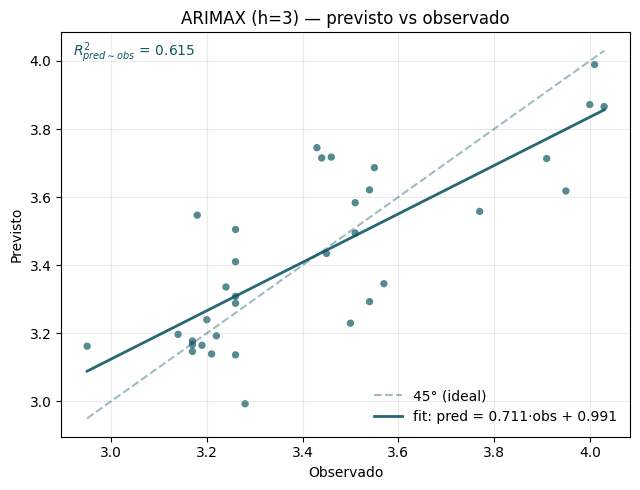

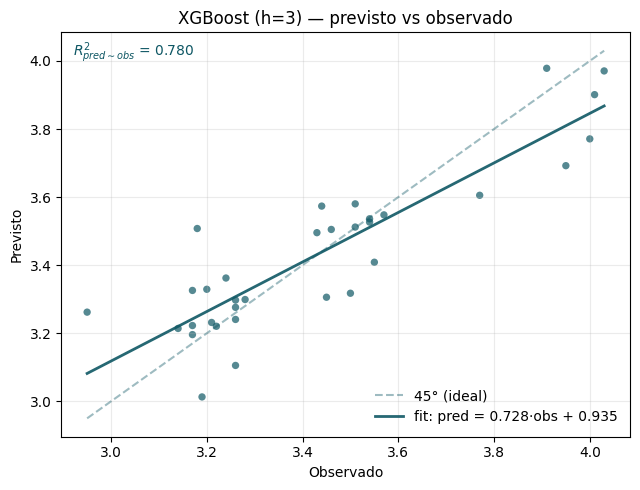

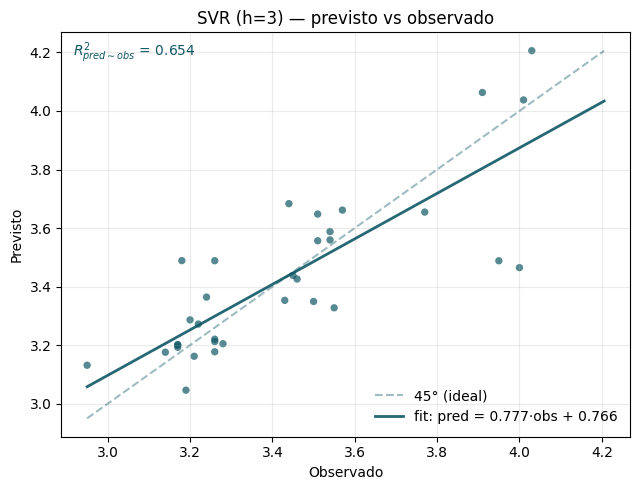

In [11]:
# =========================
# Gráficos de regressão — H=3 (previsto vs observado)
# Requisitos: já ter y_true_h3 / yhat_h3_bc, y_true_h3_xgb / yhat_xgb_h3_bc,
#             y_true_h3_svr / yhat_svr_h3_bc
# =========================
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# (Opcional) aplicar estilo Times + cor padrão, caso ainda não esteja setado
# from cycler import cycler
# import matplotlib as mpl
# COLOR = "#0e5764"
# mpl.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif", "serif"],
#     "axes.prop_cycle": cycler(color=[COLOR]),
#     "axes.edgecolor": COLOR, "xtick.color": COLOR, "ytick.color": COLOR, "text.color": COLOR,
# })

COLOR = "#0e5764"

def plot_regressao(y_true: pd.Series, y_pred: pd.Series, titulo: str):
    # alinhar e dropar NaN
    df = pd.concat([y_true.rename("obs"), y_pred.rename("pred")], axis=1).dropna()
    x = df["obs"].values.reshape(-1,1)
    y = df["pred"].values

    # ajuste linear pred ~ obs
    lr = LinearRegression().fit(x, y)
    slope = float(lr.coef_[0]); intercept = float(lr.intercept_)
    r2 = lr.score(x, y)

    # limites p/ diagonal
    xy_min = float(np.nanmin([df["obs"].min(), df["pred"].min()]))
    xy_max = float(np.nanmax([df["obs"].max(), df["pred"].max()]))

    plt.figure(figsize=(6.5, 5))
    # pontos
    plt.scatter(df["obs"], df["pred"], s=28, alpha=0.7, edgecolors="none", color=COLOR)
    # diagonal 45°
    plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=1.5, alpha=0.4, color=COLOR, label="45° (ideal)")
    # reta ajustada
    xx = np.linspace(xy_min, xy_max, 100)
    yy = slope*xx + intercept
    plt.plot(xx, yy, linewidth=2.0, alpha=0.9, color=COLOR, label=f"fit: pred = {slope:.3f}·obs + {intercept:.3f}")

    plt.title(titulo)
    plt.xlabel("Observado")
    plt.ylabel("Previsto")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="best", frameon=False)
    # anotação do R² (da regressão pred~obs)
    plt.text(0.02, 0.98, f"$R^2_{{pred\\sim obs}}$ = {r2:.3f}", transform=plt.gca().transAxes,
             ha="left", va="top", fontsize=10, color=COLOR)
    plt.tight_layout()
    plt.show()

# === ARIMAX (h=3) — usando a versão com bias ===
plot_regressao(y_true_h3, yhat_h3_bc, "ARIMAX (h=3) — previsto vs observado")

# === XGBoost (h=3) — usando a versão com bias ===
plot_regressao(y_true_h3_xgb, yhat_xgb_h3_bc, "XGBoost (h=3) — previsto vs observado")

# === SVR (h=3) — usando a versão com bias ===
plot_regressao(y_true_h3_svr, yhat_svr_h3_bc, "SVR (h=3) — previsto vs observado")